# ✈️ Flight Delay Predictor
**Goal:** Predict whether a US domestic flight will be delayed by more than 15 minutes.  
**Dataset:** [US DOT Flight Delays 2015 — Kaggle](https://www.kaggle.com/datasets/usdot/flight-delays)  
**Model:** LightGBM

## 1 — Imports

In [ ]:
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import  f1_score, roc_auc_score

## 2 — Load & Clean Data

In [ ]:
cols = [
    'MONTH',
    'DAY_OF_WEEK',
    'AIRLINE',
    'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT',
    'SCHEDULED_DEPARTURE',
    'DISTANCE',
    'ARRIVAL_DELAY',
    'CANCELLED'
]

df = pd.read_csv('data/flights.csv', usecols=cols)

print("Rows loaded:", len(df))


# =========================
# STRICT DATA CLEANING
# =========================

# Remove cancelled flights
df = df[df['CANCELLED'] == 0]

# Check missing values
print("\nMissing values before cleaning:\n")
print(df.isnull().sum())

# Remove missing values
df = df.dropna()

# Remove duplicate rows
df = df.drop_duplicates()

# Keep valid airport codes
df = df[df['ORIGIN_AIRPORT'].str.match(r'^[A-Z]{3}$', na=False)]
df = df[df['DESTINATION_AIRPORT'].str.match(r'^[A-Z]{3}$', na=False)]

# Validate departure time properly
hours = df['SCHEDULED_DEPARTURE'] // 100
minutes = df['SCHEDULED_DEPARTURE'] % 100

df = df[
    (hours >= 0) & (hours <= 23) &
    (minutes >= 0) & (minutes <= 59)
]

# Remove impossible distances
df = df[df['DISTANCE'] > 50]

# Remove extreme delay outliers
df = df[
    (df['ARRIVAL_DELAY'] > -60) &
    (df['ARRIVAL_DELAY'] < 300)
]

# Remove invalid months
df = df[
    (df['MONTH'] >= 1) &
    (df['MONTH'] <= 12)
]

# Remove invalid weekdays
df = df[
    (df['DAY_OF_WEEK'] >= 1) &
    (df['DAY_OF_WEEK'] <= 7)
]

print("\nRows after strict cleaning:", len(df))

C:\Users\shara\AppData\Local\Temp\ipykernel_30468\2031303059.py:13: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/flights.csv', usecols=cols)


Rows loaded: 5819079

Missing values before cleaning:

MONTH                      0
DAY_OF_WEEK                0
AIRLINE                    0
ORIGIN_AIRPORT             0
DESTINATION_AIRPORT        0
SCHEDULED_DEPARTURE        0
DISTANCE                   0
ARRIVAL_DELAY          15187
CANCELLED                  0
dtype: int64

Rows after strict cleaning: 5072314
Data cleaning complete.


## 3 — Feature Engineering

In [41]:
# Convert HHMM → hour
df['HOUR'] = (df['SCHEDULED_DEPARTURE'] // 100).astype(int)

# Target column
# 1 = delayed more than 15 mins
df['DELAYED'] = (df['ARRIVAL_DELAY'] > 15).astype(int)

print("Delay rate:", round(df['DELAYED'].mean() * 100, 2), "%")


Delay rate: 18.75 %


## 4 — Col -> Category & Encoding + Splitting

In [42]:
cat_cols = [
    'AIRLINE',
    'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT'
]

for col in cat_cols:
    df[col] = df[col].astype('category')

features = [
    'AIRLINE',
    'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT',
    'HOUR',
    'MONTH',
    'DAY_OF_WEEK',
    'DISTANCE'
]

X = df[features]
y = df['DELAYED']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

Training rows: 4057851
Testing rows : 1014463


## 5 — Train LightGBM

In [ ]:
model = lgb.LGBMClassifier(
    objective='binary',  # means binary classification
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=127,
    max_depth=10,
    class_weight='balanced', # Gives more importance to delayed flights so the model does not ignore the minority class.
    random_state=42
)

model.fit(
    X_train,
    y_train,
    categorical_feature=cat_cols
)

print("Training complete")

[LightGBM] [Info] Number of positive: 761039, number of negative: 3296812
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027401 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 824
[LightGBM] [Info] Number of data points in the train set: 4057851, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training complete


## 6 — Metrics

In [50]:
# Probability of delay
y_prob = model.predict_proba(X_test)[:, 1]

# Convert probability into final prediction
threshold = 0.4

y_pred = (y_prob >= threshold).astype(int)

f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("F1 Score  :", round(f1, 3))
print("ROC-AUC   :", round(auc, 3))

F1 Score  : 0.382
ROC-AUC   : 0.701


f1 score predicts how well model correctly identifies delayed flights while avoiding wrong delay predictions 
The model can detect some delayed flights, but still makes many mistakes.

roc auc measures how well the model seperates delayed flights from non delayed flights overall
The model learned meaningful patterns and performs clearly better than random guessing.

## 7 - Predict

In [ ]:
sample = pd.DataFrame({
    'AIRLINE': ['AA'],
    'ORIGIN_AIRPORT': ['JFK'],
    'DESTINATION_AIRPORT': ['LAX'],
    'HOUR': [18],
    'MONTH': [6],
    'DAY_OF_WEEK': [5],
    'DISTANCE': [2475]
})

# Convert categorical columns
for col in cat_cols:
    sample[col] = sample[col].astype('category')

# Predict probability
prob = model.predict_proba(sample)[0][1]

print("Delay Probability :", round(prob * 100, 2), "%")

if prob >= 0.4:
    print("Prediction : DELAYED")
else:
    print("Prediction : ON TIME")

Delay Probability : 55.02 %
Prediction : DELAYED


## 8 — Visualization

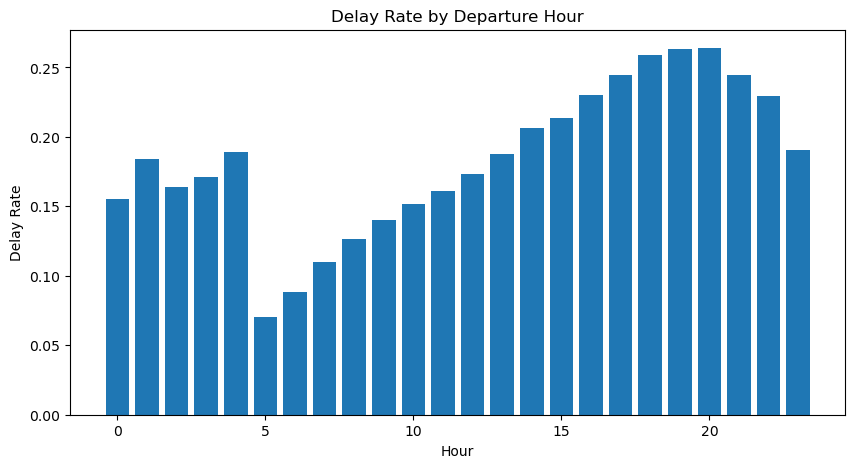

In [ ]:
hour_delay = df.groupby('HOUR')['DELAYED'].mean()

plt.figure(figsize=(10, 5))

plt.bar(hour_delay.index, hour_delay.values)

plt.title("Delay Rate by Departure Hour")
plt.xlabel("Hour")
plt.ylabel("Delay Rate")

plt.show()